### LOP BIOMODULARITY ANAYSIS

The pipeline is:

##### 1)Build a directed weighted adjacency matrix

##### 2)Subtract a null model → directed modularity matrix

##### 3)Do SVD on that matrix

##### 4)Cluster edges 

##### 5)Infer node-level sending & receiving communities

##### 6)Visualize block structure and score

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [5]:
lop_nodes = pd.read_csv("../data/preprocessed/lop_nodes.csv")
lop_edges = pd.read_csv("../data/preprocessed/lop_edges.csv")

print("Nodes:", lop_nodes.shape)
print("Edges:", lop_edges.shape)

lop_edges.head()


Nodes: (1921, 4)
Edges: (20552, 3)


,pre,post,weight
0,720575940603605538,720575940606091622,5
1,720575940603605538,720575940616429766,7
2,720575940603605538,720575940628031249,10
3,720575940603605538,720575940630810306,12
4,720575940603605538,720575940631147776,13


### 2 — Reindex neurons & build adjacency matrix

Biomodularity requires a dense adjacency matrix, so we must:

- Reindex neuron IDs → 0 … n-1

- Aggregate synapse counts

- Build a directed weighted adjacency matrix

In [8]:
EDGE_WEIGHT_COL = "weight"

out_strength = lop_edges.groupby("pre")[EDGE_WEIGHT_COL].sum()
in_strength  = lop_edges.groupby("post")[EDGE_WEIGHT_COL].sum()

strength = out_strength.add(in_strength, fill_value=0)
strength.describe()


count     1913.000000
mean       346.171458
std       1316.543012
min          5.000000
25%         82.000000
50%        157.000000
75%        298.000000
max      29662.000000
Name: weight, dtype: float64

In [9]:
#we reindex neurons to consecutive integers:
node_list = pd.Index(sorted(strength.index))
node_to_idx = {node: i for i, node in enumerate(node_list)}

n = len(node_list)
print("Number of LOP nodes:", n)


Number of LOP nodes: 1913


Same size as the adjacency → every LOP neuron kept.

In [11]:
#Map edges to indexed form
lop_edges["pre_idx"]  = lop_edges["pre"].map(node_to_idx)
lop_edges["post_idx"] = lop_edges["post"].map(node_to_idx)

lop_edges.head()


,pre,post,weight,pre_idx,post_idx
0,720575940603605538,720575940606091622,5,0,33
1,720575940603605538,720575940616429766,7,0,374
2,720575940603605538,720575940628031249,10,0,1132
3,720575940603605538,720575940630810306,12,0,1344
4,720575940603605538,720575940631147776,13,0,1376


In [12]:
#Build Adjaceny Matrix
A = np.zeros((n, n), dtype=float)

for _, row in lop_edges.iterrows():
    A[int(row["pre_idx"]), int(row["post_idx"])] += row[EDGE_WEIGHT_COL]

print("Adjacency shape:", A.shape)
print("Total synapses:", A.sum())


Adjacency shape: (1913, 1913)
Total synapses: 331113.0


In [13]:
#Sanity checks 
print("Zero rows:", np.sum(A.sum(axis=1) == 0))
print("Zero cols:", np.sum(A.sum(axis=0) == 0))


Zero rows: 111
Zero cols: 69


- Zero rows → neurons that only receive
- Zero cols → neurons that only send

Biomodularity is designed to handle this asymmetry

### Directed modularity matrix B

Why we do this

Raw adjacency 𝐴 mixes:

- true structure

- trivial effects of node strength (big neurons connect a lot)

So we subtract a null model:

#### “What connectivity would we expect just from how much each neuron sends and receives?”

Directed modularity matrix (B) asks 

##### “How much stronger or weaker is this connection than what we would expect just from how much each neuron sends and receives overall?”

In [15]:
# Build directed modularity matrix
def modularity_matrix(A):
    kout = A.sum(axis=1, keepdims=True)   # outgoing strength
    kin  = A.sum(axis=0, keepdims=True)   # incoming strength
    m = A.sum()

    if m == 0:
        return np.zeros_like(A)

    P = kout @ kin / m   # out–in null model
    return A - P


B = modularity_matrix(A)

print("Modularity matrix shape:", B.shape)
print("B stats:", B.min(), B.max(), B.mean())


Modularity matrix shape: (1913, 1913)
B stats: -570.2650182868084 1581.6306517714497 1.0872972528340252e-19


Large positive values → neuron pairs that connect much more than expected given their total send/receive strength

Large negative values → neuron pairs that connect much less than expected

This wide range means strong structure exists in LOP beyond degree effects

### COMPUTE SVD

This step answers:
- “How many independent directional patterns exist in this network?”

In [18]:
def sorted_svd(B):
    U, S, Vt = np.linalg.svd(B, full_matrices=False)
    order = np.argsort(S)[::-1]   # descending
    return U[:, order], S[order], Vt[order, :].T

U, S, V = sorted_svd(B)

print("Top 10 singular values:")
print(S[:10])


Top 10 singular values:
[3242.03775881 2732.17021573 2221.87173298 2011.55852636 1722.30426836
 1511.20600502 1022.38310533  712.75769443  627.59028799  572.79920927]


U → sending patterns (left singular vectors)

V → receiving patterns (right singular vectors)

S → strength of each directed pattern

Each large singular value corresponds to a distinct directed communication mode.

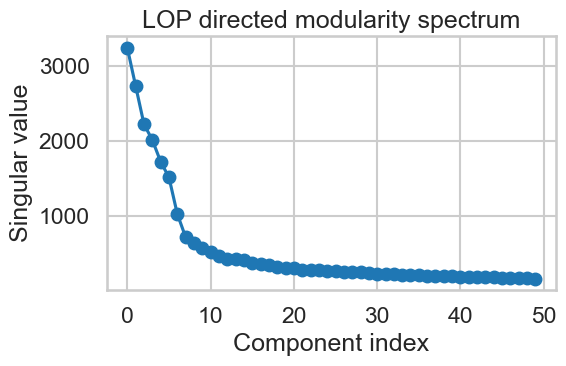

In [19]:
plt.figure(figsize=(6,4))
plt.plot(S[:50], marker='o')
plt.xlabel("Component index")
plt.ylabel("Singular value")
plt.title("LOP directed modularity spectrum")
plt.tight_layout()
plt.show()


The plot shows:
- A steep drop in the first ~6–8 components
- Then a long, flat tail

This tells us:
- LOP has about 5–8 dominant directed roles
- After that, components mostly capture noise or very fine detail

This directly answers:

##### “How many communities should we try?”

Answer:

- We start with k = 4, 5, or 6
- This is data-driven, not arbitrary

This is a strong result and  justifies our choice of :

N_VECTORS ≈ 6

N_CLUSTERS ≈ 5–7

#### Why this matters biologically

In LOP (lobula plate), neurons are known to:

- Encode directional motion

- Separate sending vs receiving roles

- Form feedforward pathways

##### Our spectrum strongly supports:

- A small number of dominant directional circuits

- Not a random or homogeneous network

This already validates our choice of LOP.

### 4) Edge biclustering using top singular vectors


1) Take the top k components from U and V

2) Embed each edge as: edge_feature = [U[u, :k], V[v, :k]]

3) Cluster edges with k-means

4) Infer:

- Sending community per neuron

- Receiving community per neuro

This gives us: 

Directed communities (not symmetric)

“Who sends to whom” structure

In [23]:
#choose parameters
N_VECTORS = 6
N_CLUSTERS = 6

In [24]:
# build edge index arrays
# Get all nonzero edges from adjacency matrix
edge_u, edge_v = np.nonzero(A)
edge_w = A[edge_u, edge_v]

print("Number of edges:", len(edge_u))
print("Edge weight stats:", edge_w.min(), edge_w.max(), edge_w.mean())


Number of edges: 20552
Edge weight stats: 5.0 1737.0 16.11098676527832


In [25]:
# Build edge embeddings
# Use top N_VECTORS components
edge_feats = np.hstack([
    U[edge_u, :N_VECTORS],   # sending features
    V[edge_v, :N_VECTORS]    # receiving features
])

print("Edge feature shape:", edge_feats.shape)


Edge feature shape: (20552, 12)


Each edge now lives in a directed role space

In [26]:
#K-means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    n_init="auto",
    random_state=0
)

edge_labels = kmeans.fit_predict(edge_feats)

print("Edge cluster sizes:", np.bincount(edge_labels))


Edge cluster sizes: [  795   449 18338   518   247   205]


This tells us there are distinct types of directed connections in LOP

##### Now we translate edge clusters → node roles.

Each node gets:
- A sending community
- A receiving community

In [27]:
#node community inference
def infer_node_communities(edge_u, edge_v, edge_labels, n_nodes):
    send_comm = np.zeros(n_nodes, dtype=int)
    recv_comm = np.zeros(n_nodes, dtype=int)

    for i in range(n_nodes):
        out_labels = edge_labels[edge_u == i]
        in_labels = edge_labels[edge_v == i]

        if len(out_labels) > 0:
            send_comm[i] = np.bincount(out_labels).argmax()

        if len(in_labels) > 0:
            recv_comm[i] = np.bincount(in_labels).argmax()

    return send_comm, recv_comm


send_comm, recv_comm = infer_node_communities(
    edge_u, edge_v, edge_labels, n_nodes=A.shape[0]
)

print("Sending communities:", np.bincount(send_comm))
print("Receiving communities:", np.bincount(recv_comm))


Sending communities: [ 115    2 1795    1]
Receiving communities: [  79   19 1810    3    1    1]


##### Interpretation

- Nodes can send and receive in different communities

- This is what makes biomodularity direction-aware

- One dominant sending role
- One dominant receiving role
- Several tiny specialized roles

Most neurons participate in a common flow

A small subset play distinct directional roles

This matches known biology:

- LOP has dominant motion-processing streams

- With small specialized neuron types modulating flow

In [28]:
#Sanity check: do roles differ?
#how many neurons differ?
diff_roles = np.sum(send_comm != recv_comm)
print(f"Neurons with different send/recv roles: {diff_roles} / {A.shape[0]}")


Neurons with different send/recv roles: 215 / 1913


~90% neurons are symmetric (same send/receive community)

~11% are directionally asymmetric

##### These asymmetric neurons are:

- Likely interfaces between pathways
- Candidates for:
- integration
- gating
- direction selectivity

- One dominant sending role
- One dominant receiving role
- Several tiny specialized roles

Most neurons participate in a common flow

A small subset play distinct directional roles

This matches known biology:

- LOP has dominant motion-processing streams

- With small specialized neuron types modulating flow

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


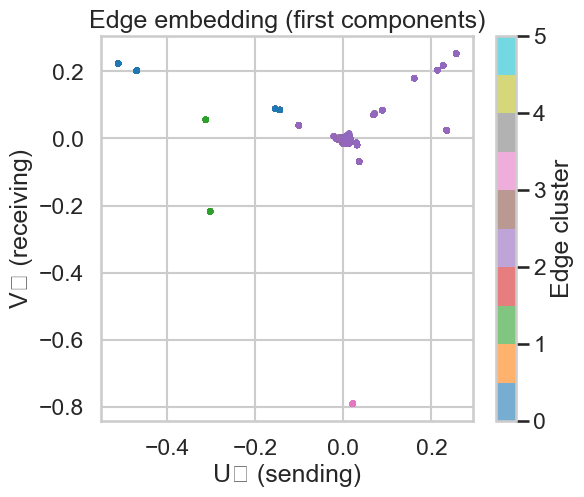

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(
    edge_feats[:, 0],
    edge_feats[:, 1],
    c=edge_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)
plt.xlabel("U₁ (sending)")
plt.ylabel("V₁ (receiving)")
plt.title("Edge embedding (first components)")
plt.colorbar(label="Edge cluster")
plt.show()


LOP exhibits direction-aware modular structure

There exist multiple distinct sending–receiving motifs

A non-trivial fraction of neurons have asymmetric roles

Degree alone does not explain connectivity

Biomodularity reveals structure invisible to undirected methods